# **Bright Stars around M67 with ADQL**

Code component of Question 2 of ASTR4004 Problem Set 2. See assignment write-up for full answer to Question 2.

**A colleague is interested in the open cluster Messier 67 ($\mathrm{RA} = 132.825\deg$, $\mathrm{Dec} = 11.8\deg$) and is considering an observation proposal using the 2dF fibre positioner and HERMES spectrography (effective for Gaia $G < 14$) to follow up stars observed with the APOGEE spectrograph, for which they only have 2MASS catalogue identifiers.**

**Your task is to assist by querying Gaia DR3 and performing some basic analysis.**

## **PART A**

**Write an ADQL query that returns all stars in the Gaia DR3 `gaiadr3.gaia_source` table within $1\deg$ of M67 with $G<14$ (`phot_g_mean_mag`) and crossmatches them with 2MASS (`gaiadr1.tmass_original_valid`). You can execute the query on the Gaia archive website or via `astroquery`. Include your ADQL query in the notebook and report the number of returned stars.**

Import necessary packages.

In [1]:
# packages handling arrays
import numpy as np
import pandas as pd
# package for data visualisation
import matplotlib.pyplot as plt
# astroquery for accessing the Gaia archive
from astroquery.gaia import Gaia

Define ADQL query for `gaiadr3.gaia_source` stars that also exist in `gaiadr1.tmass_original_valid`. We require `phot_g_mean_mag`, `ph_qual`, `parallax`, `bp_rp`, `j_m`, `h_m`, and `ks_m`. Constrain results by `phot_g_mean_mag < 14` and RA/Dec within `1.0` degrees of the M67 coordinates.

In [ ]:
adql_query = """
SELECT
  g3.source_id,
  tm.designation,
  g3.ra,
  g3.dec,
  g3.phot_g_mean_mag,
  g3.parallax,
  g3.bp_rp,
  tm.ph_qual,
  tm.j_m,
  tm.h_m,
  tm.ks_m
  
FROM gaiadr3.gaia_source AS g3

JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS xm_t
  USING (source_id)

JOIN gaiadr3.tmass_psc_xsc_join AS join_t
  ON xm_t.original_ext_source_id = join_t.original_psc_source_id

JOIN gaiadr1.tmass_original_valid AS tm
  ON join_t.original_psc_source_id = tm.designation

WHERE
  DISTANCE(132.825, 11.8, g3.ra, g3.dec) < 1.0
  AND g3.phot_g_mean_mag < 14
"""

Run query through astroquery.

In [20]:
job = Gaia.launch_job_async(adql_query)
xmatch_res = job.get_results()
display(xmatch_res.to_pandas().head())
print(adql_query)

INFO: Query finished. [astroquery.utils.tap.core]


,source_id,designation,ra,dec,phot_g_mean_mag,parallax,bp_rp,ph_qual,j_m,h_m,ks_m
0,605038438194455040,08540876+1214385,133.536443,12.244015,13.849899,1.262848,0.843878,AAA,12.795,12.487,12.440
1,605002944585123968,08514577+1217052,132.940734,12.284795,11.045901,0.717632,1.178664,AAA,9.548,9.056,8.902
2,604994904406431360,08501807+1217166,132.575268,12.287914,13.175420,0.772515,0.732261,AAA,12.272,11.983,11.939
3,605008957539330816,08515260+1218538,132.969140,12.314941,12.348717,0.265257,1.463181,AAA,10.478,9.797,9.633
4,605009949676900352,08513862+1220141,132.910887,12.337297,12.697912,1.167491,1.093849,AAA,11.298,10.866,10.791



SELECT
  g3.source_id,  -- Gaia DR3 ID
  tm.designation,  -- 2MASS ID
  g3.ra,  -- Gaia RA
  g3.dec,  -- Gaia Dec
  g3.phot_g_mean_mag,  -- Gaia G mag
  g3.parallax,  -- Gaia parallax
  g3.bp_rp,  -- Gaia BP-RP
  tm.ph_qual,  -- 2MASS photometry flag
  tm.j_m,  -- 2MASS J mag
  tm.h_m,  -- 2MASS H mag
  tm.ks_m  -- 2MASS Ks mag

FROM gaiadr3.gaia_source AS g3

JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS xm_t
  USING (source_id)

JOIN gaiadr3.tmass_psc_xsc_join AS join_t
  ON xm_t.original_ext_source_id = join_t.original_psc_source_id

JOIN gaiadr1.tmass_original_valid AS tm
  ON join_t.original_psc_source_id = tm.designation

WHERE
  DISTANCE(132.825, 11.8, g3.ra, g3.dec) < 1.0  -- cone search within 1 deg
  AND g3.phot_g_mean_mag < 14  -- HERMES limit (given in Q)



Write to `.csv` file in `data/`. 

In [ ]:
# write table to .csv file without row numbers (index=False)
xmatch_res.to_pandas().to_csv("data/q2_xmatch_res.csv", index=False)

Read in `.csv` file and determine data length.

In [24]:
data = pd.read_csv("data/q2_xmatch_res.csv") # read-in xmatch data
print("No. Stars: "+str(len(data))) # print len of data

No. Stars: 1018


## **PART B**

**Identify stars with: bad 2MASS photometry (`ph_qual` is not `"AAA"`); non-positive values of Gaia `parallax`. Apply these quality cuts and report how many stars remain.**

Remove stars with `ph_qual != "AAA"` and `parallax < 0`.

In [ ]:
# define array mask based on quality reqs
qual_mask = (
    (data["ph_qual"] == "AAA") & # ph_qual must equal "AAA" AND
    (data["parallax"] >= 0) # parallax greater than or equal to 0
)
# apply mask
clean_data = data[qual_mask]

Write to `.csv` file in `data/`.

In [ ]:
clean_data.to_csv("data/q2_clean.csv", index=False)

Read in clean data file and determine clean data length.

In [2]:
clean_data = pd.read_csv("data/q2_clean.csv") # read-in xmatch data
print("No. Clean Stars: "+str(len(clean_data))) # print len of data

No. Clean Stars: 988


## **PART C**

**Create and save a two-panel figure showing: Gaia $BP-RP$ versus absolute $G$ magnitude, using `bp_rp`; 2MASS $J-Ks$ versus apparent $H$ magnitude, using `j_m`, `h_m`, and `ks_m`.**

Define variables for each subplot.

In [3]:
y_g3 = clean_data["bp_rp"] # gaia subplot y-axis (BP-RP)
x_g3 = clean_data["phot_g_mean_mag"] # gaia x-axis (G)
y_tm = clean_data["j_m"] - clean_data["ks_m"] # 2mass y (J-Ks)
x_tm = clean_data["h_m"] # 2mass x (H)

Create 2-subplot figure and save.

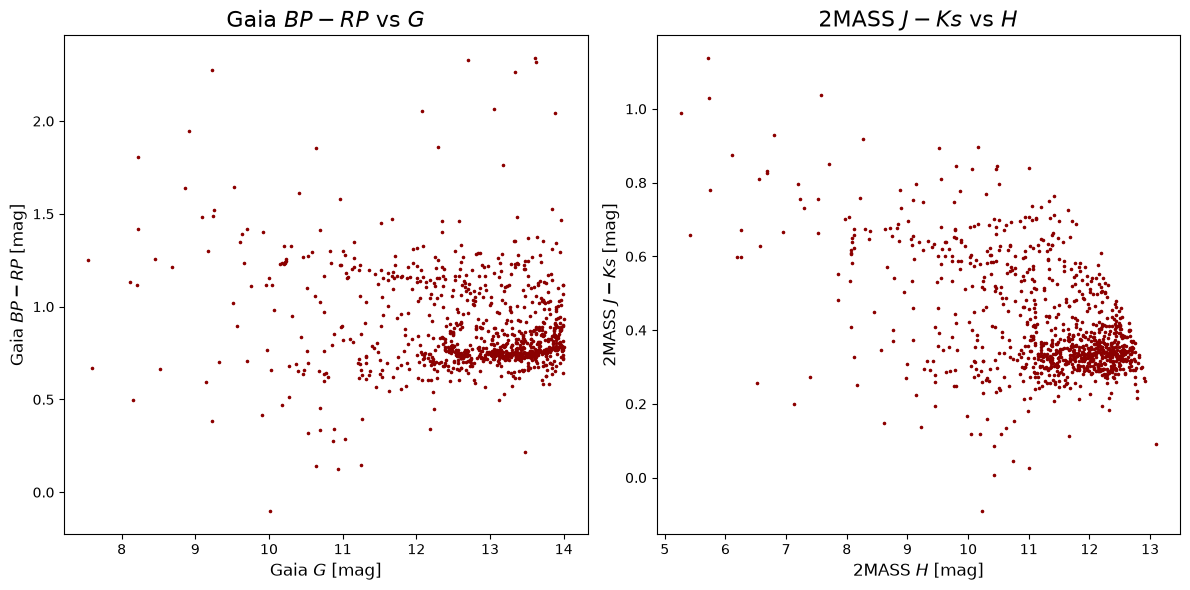

In [8]:
# define figure with two horizontally-stacked subplots
fig, axs = plt.subplots(1, 2, figsize=(12,6), sharex=False, sharey=False)

# gaia (left) panel
ax = axs[0]
ax.scatter(x_g3, y_g3, c="DarkRed", marker=".", s=10) 
ax.set_title(r"Gaia $BP-RP$ vs $G$", fontsize=16) # panel title
ax.set_xlabel(r"Gaia $G$ [mag]", fontsize=12) # x axis label
ax.set_ylabel(r"Gaia $BP-RP$ [mag]", fontsize=12) # y label

# 2mass (right) panel
ax = axs[1]
ax.scatter(x_tm, y_tm, c="DarkRed", marker=".", s=10)
ax.set_title(r"2MASS $J-Ks$ vs $H$", fontsize=16)
ax.set_xlabel(r"2MASS $H$ [mag]", fontsize=12)
ax.set_ylabel(r"2MASS $J-Ks$ [mag]", fontsize=12)

plt.tight_layout() # minimise whitespace around/between panels
plt.savefig("figures/q2c_g3_v_tm.png", dpi=200) # save to figures/
plt.show() # display figure